# IGR Workshop 2: Field Hillslope Profile Processing
Sim M. Reaney, IGR, 2026.  
During your fieldwork at Langdon Beck, you collected data for a number of hillslope profiles using both the handheld GPS units and the distance-angle approach. This workshop focuses on processing these hillslope profile data using Python. We will cover data loading, cleaning, analysis, and visualisation techniques. By the end of this workshop, you will be able to:
1. Load and process hillslope profile data.
2. Visualise hillslope profiles.
3. Perform statistical analysis on hillslope profile data to compare it with a profile extracted from a LiDAR DEM.
4. Use new Python packages, inclduing _numpy_ for numerical operations, _rasterio_ for working with LiDAR DEMs, and _scipy_ for statistical analysis.

## Why are hillslope profiles important?
Hillslope profiles provide critical insights into the geomorphology and hydrology of a landscape. They help us understand processes such as erosion, sediment transport, and water flow. By analysing hillslope profiles, we can make informed decisions about land management, conservation, and environmental planning. Where there is a convex profile, we might expect higher erosion rates, while concave profiles may indicate areas of sediment deposition. Steeper slopes can lead to faster runoff and increased flood risk, while gentler slopes may promote infiltration and groundwater recharge. Steeper slopes can also be more prone to landslides, especially in areas with loose or unstable soils.



## 1. Reading in the data. 
The first step is to read in the hillslope profile data collected in the field. This data is stored in a CSV file format. We will use the pandas library to read the data into a Pandas DataFrame for easier manipulation and analysis. The CSV file contains columns for distance, angle, and elevation measurements taken along the hillslope profile from both the distance-angle methods and from the GPS. We need to read in a sample profile here to develop the code and later in the workshop, you will apply this to your own data. The fist part of this block needs to import the pandas library and import the data from the csv file held on a GitHub page.: 

```python
import pandas as pd
# Read in the hillslope profile data
df = pd.read_csv('https://simreaney.github.io/IGR/WS02/survey.csv') 
```

Once the data is read in, we can take a look at the first few rows of the DataFrame to understand its structure. To do this, we can use the `head()` method of the DataFrame. There are also other useful methods such as `tail()`, `info()` and `describe()` that can provide insights into the data types and summary statistics of the columns.

```python
# Display the first few rows of the DataFrame
print(df.head())
```     
This command will give you an overview of the data and help you identify the columns that contain the distance, angle, and elevation measurements. You can then proceed to process this data for further analysis and visualisation.    

In [11]:
# Below this line, you need to implement the importing code

import pandas as pd

df = pd.read_csv('https://simreaney.github.io/IGR/WS02/survey.csv') 

print(df.head())

   surveyDistance  surveyAngle  GPS_x  GPS_y  GPS_alt
0             0.0          0.0  85125  33923      483
1             5.0         -2.5  85128  33918      481
2             7.0         -4.5  85129  33911      482
3             7.0         -4.0  85132  33904      481
4             5.0         -6.0  85135  33899      482


## 2. Processing the distance-angle data and visualising the hillslope profile
To process the distance-angle data into a distance-elevation format, we need to convert the angles into elevation changes. We can use trigonometric functions to calculate the elevation at each point along the hillslope profile. The first step is to import the numpy library fror the trig functions and matplotlib for plotting:   

```python
import numpy as np
import matplotlib.pyplot as plt    
 ```

Next we need to extend the dataframe to include the distance and altitudes from the survey. We do this with the following two commands. These command create two new columns in the dataframe and initialise the values for each row to zero. 

```python  
df['distanceSurvey'] = 0.0
df['altSurvey'] = 0.0
```

If you run ```df.head()``` again, you will see the new columns added to the dataframe. Now we can calculate the elevation changes and cumulative elevation using the distance and angle data. Before starting the calculations, you need to set a starting altitude for the profile. This is done with the following line of code which takes the first GPS altitude measurement as the starting point.

```python  
startAlt = df['GPS_alt'].iloc[0]
```
Now you can proceess through the field data to process the distance-angle data into distance-elevation format. The following code  does these calcualtions:

* To do this calculation you need to use a for loop that works it way though each of the field measirements. This is set up with the for i in range(0, len(df)) line. The len(df) gives you the length (number of rows) of field data that were imported. 
* Inside the for loop, you need to convert the survey angle from degrees to radians using the np.deg2rad() function. This is necessary because the trigonometric functions in Python and numpy use radians.
* Next, calculate the change in altitude (altChange) using the tangent of the angle multiplied by the survey distance.
* Then, update the cumulative distance and altitude for each point in the DataFrame. For the first point (i == 0), set the distance and altitude directly. For subsequent points, add the current distance and altitude changes to the previous values.
* You can use the .at[] method to update specific cells in the DataFrame. The first argument is the row index, and the second argument is the column name and then after the = sign you put the value you want to assign to that cell.

```python  
for i in range(0, len(df)):
    angleRad = np.deg2rad(df["surveyAngle"].iloc[i])
    altChange = df["surveyDistance"].iloc[i] * np.tan(angleRad)
    
    if i == 0:
        df.at[i, "distanceSurvey"] = df["surveyDistance"].iloc[i]
        df.at[i, "altSurvey"] = startAlt + altChange
    else:
        df.at[i, "distanceSurvey"] = df.at[i-1, "distanceSurvey"] + df["surveyDistance"].iloc[i]
        df.at[i, "altSurvey"] = df.at[i-1, "altSurvey"] + altChange
```

Here, you can see that we have used an if-else statement to handle the first point differently from the rest. This ensures that the cumulative distance and altitude are calculated correctly. If-else statements are very useful in programming for handling different conditions and scenarios. The '==' operator is used to check for equality, while the '=' operator is used for assigning one value to another, such as x = 2 makes the value held in x be the value 2, whereas x==2 will return True if teh value in x is 2 or False if it is not a value of 2.

Again, you can use df.head() to check that the new columns have been populated correctly.


In [ ]:
# Below this line, you need to implement the code for processing the data
import matplotlib.pyplot as plt
import numpy as np

df['distanceSurvey'] = 0.0
df['altSurvey'] = 0.0

startAlt = df['GPS_alt'].iloc[0]

for i in range(0, len(df)):
    angleRad = np.deg2rad(df["surveyAngle"].iloc[i])
    altChange = df["surveyDistance"].iloc[i] * np.tan(angleRad)
    
    if i == 0:
        df.at[i, "distanceSurvey"] = df["surveyDistance"].iloc[i]
        df.at[i, "altSurvey"] = startAlt + altChange
    else:
        df.at[i, "distanceSurvey"] = df.at[i-1, "distanceSurvey"] + df["surveyDistance"].iloc[i]
        df.at[i, "altSurvey"] = df.at[i-1, "altSurvey"] + altChange

print(df.head())

   surveyDistance  surveyAngle  GPS_x  GPS_y  GPS_alt  distanceSurvey  \
0             0.0          0.0  85125  33923      483             0.0   
1             5.0         -2.5  85128  33918      481             5.0   
2             7.0         -4.5  85129  33911      482            12.0   
3             7.0         -4.0  85132  33904      481            19.0   
4             5.0         -6.0  85135  33899      482            24.0   

    altSurvey  
0  483.000000  
1  482.781695  
2  482.230783  
3  481.741296  
4  481.215774  


## 3. Visulaising the hillslope profile
You can now visualise the processed hillslope profile using matplotlib. The You need to look at your code from last week on how to make a graph. You need to create a simple line plot of altitude versus distance along the hillslope profile and add some new features to it as shown below. 

```python
#This is not the complete code, just the new parts to add to your code from last week.
plt.plot(df["distanceSurvey"], df["altSurvey"], marker='o', label='Survey')
plt.legend()
plt.grid(True)
```
The new aspects from last week are the additation of 
* The ```marker='o'``` argument to the plt.plot() function which adds circular markers at each data point along the profile. This makes it easier to see the individual measurements taken in the field. You can change the marker style by using different characters, such as 's' for squares or '^' for triangles.
* The ```plt.grid(True)``` that adds a grid to the plot to help with the interpreation of the profile.
* The ```label='Survey'``` argument to the plt.plot() function which adds a label to the line in the plot. This is useful when you have multiple lines on the same plot and want to distinguish between them. 
* The ```plt.legend()``` function adds a legend to the plot.

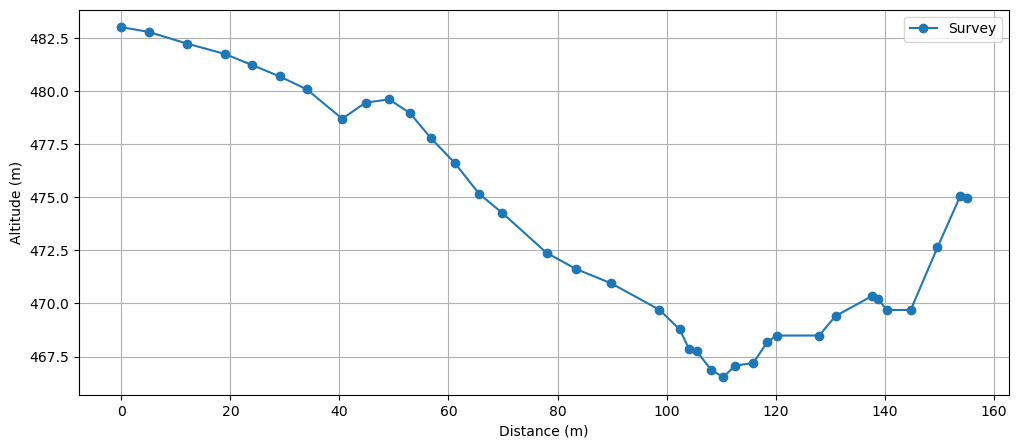

In [ ]:
# Below this line, you need to implement the graphing code
plt.figure(figsize=(12, 5))
plt.plot(df["distanceSurvey"], df["altSurvey"], marker='o', label='Survey')
plt.xlabel('Distance (m)')
plt.ylabel('Altitude (m)')
plt.legend()
plt.grid(True)
plt.show()

## 4. Creating profile from GPS points
In the field, you also collected GPS points along the hillslope profile. You can use these GPS points to create a profile and compare it with the distance-angle derived profile. The GPS data is already included in the DataFrame in the _GPS_x_, _GPS_y_ and _GPS_alt_ columns. These columns need to be converted into the distances along the profile. To do this calcualtion, we need to take the x and y differences between the pairs of points and then use Pythagoras theorem to calculate the distance. However, the GPS readings have been stored as the values within the 'NY; square of the [https://www.ordnancesurvey.co.uk/documents/resources/guide-to-nationalgrid.pdf](Ordannce Survey grid system) and hence to map correctly into space, we need to add the offset of the start of the this square to the recorded values. Do do this, we add 300 km to the easting and 500 km to the northing. The following code does this calculation.

```python
df["GPS_x"] = df["GPS_x"] + 300000 #300 km offset for easting in metres
df["GPS_y"] = df["GPS_y"] + 500000 #500 km offset for northing in metres
``` 

Next, we need to create a new column in the DataFrame to store the cumulative distance from the GPS data. We can initialise these columns to zero as before:

```python
df['distanceGPS'] = 0.0
```

Now we can process through the GPS data to calculate the cumulative distance along the profile. The following code does this calculation. Here you can see that we set the range to start at 1 rather than 0 since the distance at the first point is zero and we have already initialised this value in the line above. In the code below, we calculate the change in x (deltaX) and change in y (deltaY) between each pair of GPS points, then use Pythagoras theorem to calculate the distance between these points. We then accumulate this distance to get the total distance along the profile.

```python
for i in range(1, len(df)):
    deltaX = df["GPS_x"].iloc[i] - df["GPS_x"].iloc[i-1]
    deltaY = df["GPS_y"].iloc[i] - df["GPS_y"].iloc[i-1]
    distance = np.sqrt(deltaX**2 + deltaY**2)
    df.at[i, "distanceGPS"] = df.at[i-1, "distanceGPS"] + distance
``` 

You can now update the profile plot to include the GPS-derived profile. The following code snippet adds the GPS profile to the existing plot. You need to add this line after the previous plt.plot line in the previous plotting code. You should copy and paste your previous plotting code and just add this new line to it.

```python
plt.plot(df['distanceGPS'], df['GPS_alt'], marker='o', color='orange', label='GPS')
```
The new aspect is that you ahve specified a different color for the GPS profile using the ```color='orange'``` argument. This helps to distinguish between the two profiles on the plot.

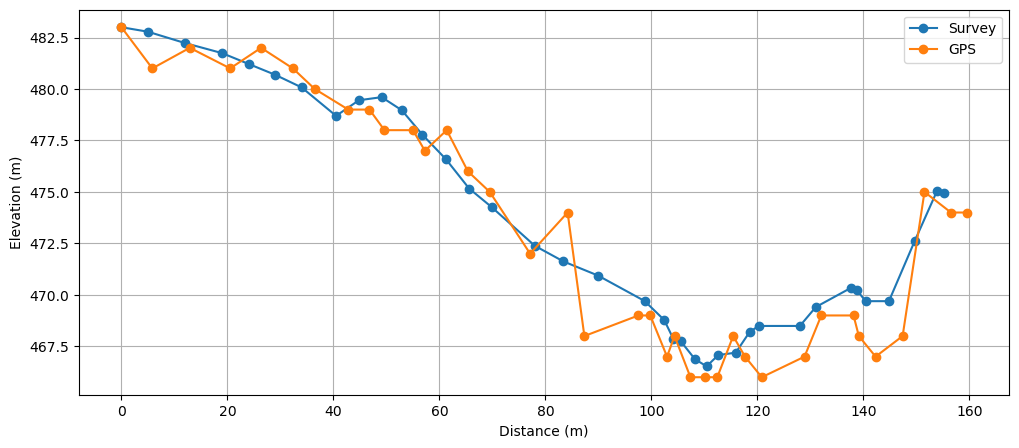

In [ ]:
# Below this line, you need to implement the importing code

df["GPS_x"] = df["GPS_x"] + 300000
df["GPS_y"] = df["GPS_y"] + 500000

df['distanceGPS'] = 0.0

for i in range(1, len(df)):
    delta_easting = df.at[i, "GPS_x"] - df.at[i-1, "GPS_x"] 
    delta_northing = df.at[i, "GPS_y"] - df.at[i-1, "GPS_y"] 
    segment_distance = np.sqrt(delta_easting**2 + delta_northing**2)
    df.at[i, "distanceGPS"]  = df.at[i-1, "distanceGPS"]  + segment_distance

plt.figure(figsize=(12, 5))
plt.plot(df["distanceSurvey"], df["altSurvey"], marker='o',label='Survey')
plt.plot(df['distanceGPS'], df['GPS_alt'], marker='o', color='orange', label='GPS')
plt.xlabel('Distance (m)')
plt.ylabel('Elevation (m)')
plt.grid(True)
plt.legend()
plt.show()




## 5. Comparing the two profiles to the LiDAR DEM
To compare the GPS-derived profile with the LiDAR-derived profile, you need to load the LiDAR DEM data. LiDAR stands for 'Light Detection And Ranging' and involves measuring the time it takes for a light beam to travel from a laser to an object and then be returned. This travel time give a highly accurate distance and is widely used for topographic mapping. This data is typically stored in a raster format, such as GeoTIFF. You can use the _rasterio_ library to read the DEM data and sample elevation values based on the GPS points. You need to import the rasterio library and then import the dataset from the GitHub page using the following code:

```python
import rasterio
from rasterio.plot import show

# Load the LiDAR DEM data
dem = rasterio.open('https://simreaney.github.io/IGR/WS02/Langdon_Beck.tif')
```

You can then visulaise the DEM data using the following code:
```python
plt.figure(figsize=(12, 5))
plt.title('DEM - Langdon Beck')
show(dem, cmap='terrain')
```
You can change the colormap by changing the value of the cmap argument to other options such as 'viridis', 'plasma', 'inferno', 'magma', or 'cividis'. There are many other [https://matplotlib.org/stable/users/explain/colors/colormaps.html](colormaps available) in matplotlib that you can explore.


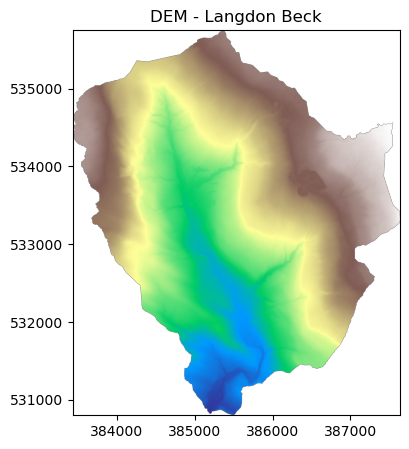

<Axes: title={'center': 'DEM - Langdon Beck'}>

In [23]:
# Below this line, you need to implement the LiDAR DEM importing and visulisation code
# Read in LiDAR data
import rasterio
from rasterio.plot import show
dem = rasterio.open('https://simreaney.github.io/IGR/WS02/Langdon_Beck.tif')

plt.figure(figsize=(12, 5))
plt.title('DEM - Langdon Beck')
show(dem, cmap='terrain')


## 5.1 Visualising the profile on the LiDAR DEM
To visualise the GPS survey points on the DEM, we can generate a zoomed in plot of the DEM around the survey points and then overplot the GPS points on top. The code in the following block creates this visulisation. However, there are three errors in the code that you need to resolve. 

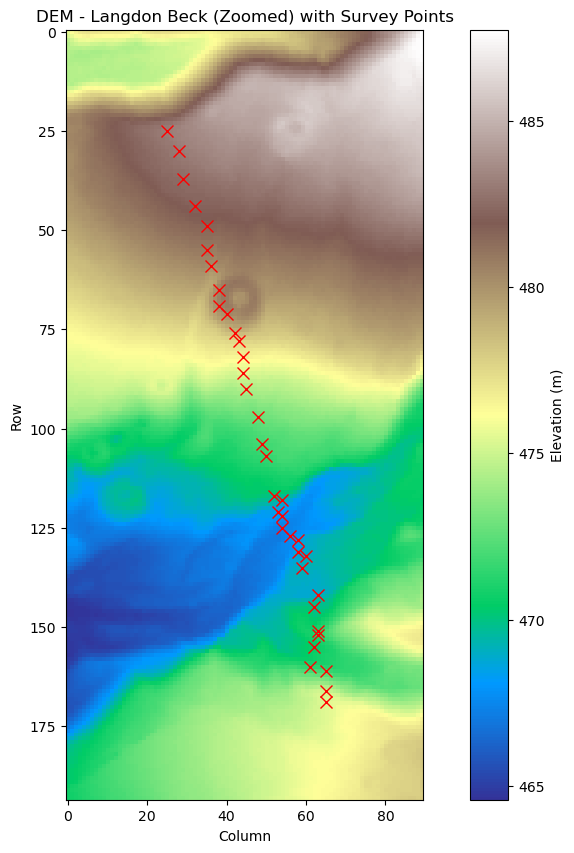

In [16]:
# Below this line, you need to implement the importing code
# Calculate bounds of survey points with buffer
buffer = 25  # meters
min_easting = min(df['GPS_x']) - buffer
max_easting = max(df['GPS_x']) + buffer
min_northing = min(df['GPS_y']) - buffer
max_northing = max(df['GPS_y']) + buffer

# Create list of (x, y) pairs for survey points
xy_pairs = list(zip(df['GPS_x'], df['GPS_y']))

# Convert to pixel coordinates
min_row, min_col = dem.index(min_easting, max_northing)
max_row, max_col = dem.index(max_easting, min_northing)

# Extract zoomed DEM
dem_array = dem.read(1)
dem_zoomed = dem_array[min_row:max_row, min_col:max_col]

# Plot zoomed DEM with survey points
plt.figure(figsize=(12, 10))
plt.imshow(dem_zoomed, cmap='terrain')
plt.colorbar(label='Elevation (m)')

# Overlay survey points
for x, y in xy_pairs:
    row, col = dem.index(x, y)
    plt.plot(col - min_col, row - min_row, 'rx', markersize=8)

plt.title('DEM - Langdon Beck (Zoomed) with Survey Points')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

## 5.2 Get LiDAR elevations for the GPS points
To sample elevation values from the DEM based on the GPS points, you can use the following code snippet:
```python
# Sample elevation values from the DEM based on GPS points
gps_elevations = [] # Initialize an empty list to store the elevation values
for i in range(len(df)):
    row, col = dem.index(df['GPS_x'].iloc[i], df['GPS_y'].iloc[i]) # Get the row and column indices for the GPS point and converts from the spatial coordinates to the raster indices
    elevation = dem.read(1)[row, col] # Read the elevation value from the DEM at the specified row and column
    gps_elevations.append(elevation) # Append the elevation value to the list of values
df['LiDAR_alt'] = gps_elevations # Add the LiDAR elevations to the DataFrame
```
You can then update the profile plot to include the LiDAR-derived profile. You need to add this line after the previous plt.plot lines in the previous plotting code. You should copy and paste your previous plotting code and just add this new line to it.
```python
plt.plot(df['distanceGPS'], df['LiDAR_alt'], marker='o', color='red', label='LiDAR')
``` 
You can now see three different profiles of the same hillslope on the same plot: the distance-angle derived profile, the GPS-derived profile, and the LiDAR-derived profile. This allows you to visually compare the different methods of obtaining hillslope profiles. However, to quantify the relationship between the profiles, we can perform statistical analysis using linear regression.

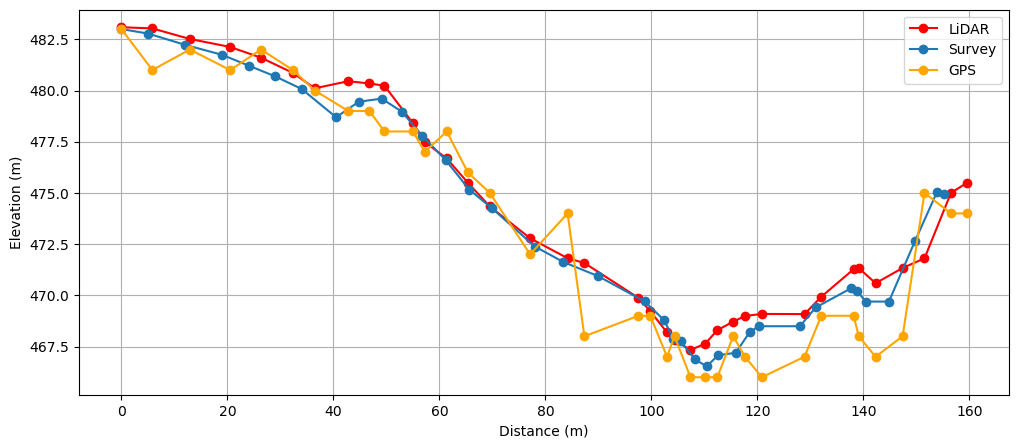

In [ ]:
# Below this line, you need to implement the code to extract the values from the DEM and plot them

gps_elevations = []
for i in range(len(df)):
    row, col = dem.index(df['GPS_x'].iloc[i], df['GPS_y'].iloc[i])
    elevation = dem.read(1)[row, col]
    gps_elevations.append(elevation)        
df['elevationsDEM'] = gps_elevations

plt.figure(figsize=(12, 5))
plt.plot(df['distanceGPS'], df['elevationsDEM'], marker='o', color='red', label='LiDAR')
plt.plot(df["distanceSurvey"], df["altSurvey"], marker='o',label='Survey')
plt.plot(df['distanceGPS'], df['GPS_alt'], marker='o', color='orange', label='GPS')
plt.xlabel('Distance (m)')
plt.ylabel('Elevation (m)')
plt.grid(True)
plt.legend()
plt.show()



## 6. Comparing the two profiles using linear regression
To quantify the relationship between the GPS-derived profile and the LiDAR-derived profile, we can use linear regression. The scipy library provides a convenient function to perform linear regression analysis. You can use the following code snippet to perform linear regression and print the results:
```python
from scipy.stats import linregress  
# Perform linear regression between GPS-derived and LiDAR-derived profiles
slope, intercept, r_value, p_value, std_err = stats.linregress(df['elevationsDEM'], df['GPS_alt'])

```
This function returns several values, including the slope and intercept of the regression line, the R-squared value (r_value), the p-value, and the standard error of the estimate. You can use these values to understand the relationship between the two profiles. In the code example below, we print the R-squared value to assess the strength of the correlation between the GPS-derived and LiDAR-derived profiles to the figure title and to the line label.

The R-squared value indicates the strength of the relationship between the two profiles. A value close to 1 indicates a strong correlation, while a value close to 0 indicates a weak correlation. the regression equation is made up of an offset and a scaling factor. The form of the equations is y = x*slope + intercept. The interspect tells you about a systematic offset between the GPS data and the LiDAR data. The slope tells you about any scaling differences between the two datasets. 



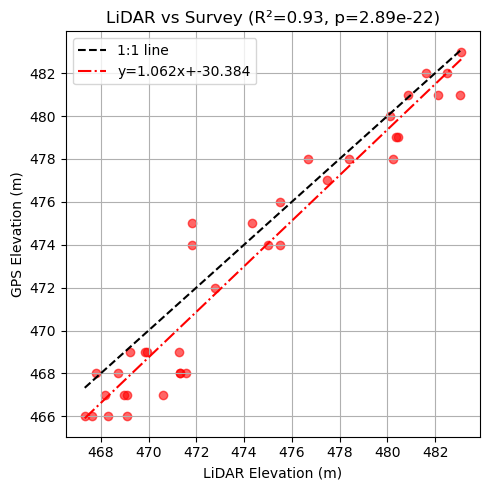

In [26]:
# Below this line, you need to implement the importing code

from scipy import stats

fig, axes = plt.subplots(figsize=(5, 5))

# LiDAR vs GPS
axes.scatter(df['elevationsDEM'], df['GPS_alt'], alpha=0.6, color='red')
axes.plot([min(df['elevationsDEM']), max(df['elevationsDEM'])], [min(df['elevationsDEM']), max(df['elevationsDEM'])], 'k--', label='1:1 line')

slope, intercept, r_value, p_value, std_err = stats.linregress(df['elevationsDEM'], df['GPS_alt'])
line_x = np.array([df['elevationsDEM'].min(), df['elevationsDEM'].max()])
line_y = slope * line_x + intercept


axes.plot(line_x, line_y, 'r-.', label=f'y={slope:.3f}x+{intercept:.3f}')

axes.set_xlabel('LiDAR Elevation (m)')
axes.set_ylabel('GPS Elevation (m)')
axes.set_title(f'LiDAR vs Survey (R²={r_value**2:.2f}, p={p_value:.2e})')
axes.grid(True)
axes.yaxis.set_major_locator(plt.MultipleLocator(2))
axes.legend()
plt.tight_layout()
plt.show()

## Cleaning and importing your own data

Next you will apply the techniques covered in this workshop to your own hillslope profile data. You need to find your groups profile in this [spreadsheet](https://durhamuniversity-my.sharepoint.com/:x:/g/personal/dgg1sr_durham_ac_uk/IQAZMKVXjCo3TYTtq3JlvfM2AUCplecUBoI7xBTsbwnDGLQ?e=g4Ynwe). you then need to prepare this data for import into Python by saving it as a CSV file. Make sure to include the five necessary column: surveyDistance, surveyAngle, GPS_x, GPS_y, GPS_alt. The steps are
* Open the spreadsheet and locate your group's hillslope profile data.
* Copy the surveyDistance, surveyAngle,GPS_x, GPS_y, GPS_alt columns for your profile into a new spreadsheet.
* Save the new spreadsheet as a CSV file (e.g., "my_hillslope_profile.csv").
* Upload the .csv file to the Files area in Colab. You need to click on the folder icon on the left-hand side of the Colab interface to open the Files pane. Then click on the upload icon (a paper with an upward arrow) to upload your CSV file from your local computer.
* Change the df.read_csv() line inthe first block to read in your own CSV file instead of the sample file used in this workshop. You need to remove the URL and replace it with the filename of your uploaded CSV file. For example, if your file is named "my_hillslope_profile.csv", you would change the line to:
```python
df = pd.read_csv('my_hillslope_profile.csv')
```

You will then be able to re-run this code to process, visualise, and analyse your own hillslope profile data. If you have problems, the following my be the cause:
* Check that the CSV file is formatted correctly with the necessary columns.
* Check for typographical errors in the column names and in the data itself.
    * It is common to have a missing digit, such as '8845' rather than '88450'.
    * Some numbers are often mis-typed, such as a '3' for and '8'. 



----
Sim M. Reaney, IGR, 2026.
https://simreaney.github.io/